# Imports

In [2]:
import requests
import json
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import os
from web3 import Web3
import pandas as pd
import numpy as np
from scipy import stats
import json
import matplotlib.pyplot as plt



/Users/ayoub/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Récupération de la Data

In [3]:
df_trades = pd.read_parquet('onchain_trades.parquet')

with open ('polymarket_markets_2023_2025.json') as f:
    df_gamma = json.load(f)

df_gamma = pd.DataFrame(df_gamma)

In [4]:
df_gamma.head()

,id,question,conditionId,slug,resolutionSource,endDate,liquidity,startDate,fee,image,...,negRiskMarketID,negRiskRequestID,acceptingOrdersTimestamp,feeSchedule,gameId,sportsMarketType,line,deployingTimestamp,eventStartTime,groupItemRange
0,248330,Will Peter Obi be elected as President of Nige...,0x47a53b22a1aeabde0bc95539e5f4bc966d92202e24fa...,will-peter-obi-be-elected-as-president-of-nige...,https://www.inecnigeria.org/elections/election...,2023-02-25T00:00:00Z,25.005021,2023-01-05T00:00:00Z,16000000000000000,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,248332,Will Bola Tinubu be elected as President of Ni...,0x99ba269df3e81aedee7938ffc5f4ca1ba3c53a8416bf...,will-bola-tinubu-be-elected-as-president-of-ni...,https://www.inecnigeria.org/elections/election...,2023-02-25T00:00:00Z,25.000022,2023-01-05T00:00:00Z,20000000000000000,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,248331,Will Atiku Abubakar be elected as President of...,0x6a3086722b7e5ba3646605202b0a87832e86c9b81ba5...,will-atiku-abubakar-be-elected-as-president-of...,https://www.inecnigeria.org/elections/election...,2023-02-25T00:00:00Z,25.659549,2023-01-05T00:00:00Z,16000000000000000,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,248365,Will Ron DeSantis file to run for president by...,0xe33a4e67ef4f211d35f0ee01558fe91f2befbfefd185...,will-ron-desantis-file-to-run-for-president-by...,https://www.fec.gov/,2023-06-30T00:00:00Z,25.01001,2023-01-09T21:24:38.031Z,16000000000000000,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,248385,"Will Biden be impeached by June 30, 2023?",0x7bb90b216f9686eeec780ca9cc89757080e613c3973e...,will-biden-be-impeached-by-june-30-2023,,2023-06-30T00:00:00Z,25.005005,2023-01-13T22:36:02.41Z,20000000000000000,https://polymarket-upload.s3.us-east-2.amazona...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_trades.head()


,block,timestamp,tx_hash,maker,taker,maker_asset_id,taker_asset_id,maker_amount,taker_amount,fee
0,69000000,1741873247,0x81846a5ed4ec472c590284ee55b39c0764c4870e9079...,0x4bbe10ba5b7f6df147c0dae17b46c44a6e562cf3,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0.000000e+00,9.578692e+76,17.082000,23.400000,0.0
1,69000000,1741873247,0x81846a5ed4ec472c590284ee55b39c0764c4870e9079...,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.578692e+76,0.000000e+00,23.400000,17.082000,0.0
2,69000004,1741873255,0xca1a48a927452ef592319a8c88fcc64b9ee903c3e240...,0xa784d06cc12f6c35c7aab3c0e48b42bd403ac046,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0.000000e+00,6.222618e+76,0.042686,2.032666,0.0
3,69000004,1741873255,0xca1a48a927452ef592319a8c88fcc64b9ee903c3e240...,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.000000e+00,1.062321e+77,1.989980,2.032666,0.0
4,69000005,1741873257,0x208f410176c1deadcd6af07352135a7247a8ca5a45d0...,0xc390fa385403669645a20d81fc672a25d1ad28bd,0x6a1c9566fd83a64a2f5d45c658d915228639e738,1.030534e+77,0.000000e+00,2.960000,1.154400,0.0


In [6]:
df_trades_copy = df_trades.copy()
df_gamma_copy = df_gamma.copy()

df_trades_copy['Date'] = pd.to_datetime(df_trades_copy['timestamp'], unit='s')
df_trades_copy.drop(columns=['timestamp', 'tx_hash', 'fee'], inplace=True)

df_trades_copy.head()

,block,maker,taker,maker_asset_id,taker_asset_id,maker_amount,taker_amount,Date
0,69000000,0x4bbe10ba5b7f6df147c0dae17b46c44a6e562cf3,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0.000000e+00,9.578692e+76,17.082000,23.400000,2025-03-13 13:40:47
1,69000000,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.578692e+76,0.000000e+00,23.400000,17.082000,2025-03-13 13:40:47
2,69000004,0xa784d06cc12f6c35c7aab3c0e48b42bd403ac046,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0.000000e+00,6.222618e+76,0.042686,2.032666,2025-03-13 13:40:55
3,69000004,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.000000e+00,1.062321e+77,1.989980,2.032666,2025-03-13 13:40:55
4,69000005,0xc390fa385403669645a20d81fc672a25d1ad28bd,0x6a1c9566fd83a64a2f5d45c658d915228639e738,1.030534e+77,0.000000e+00,2.960000,1.154400,2025-03-13 13:40:57


In [7]:
df_trades_copy.drop(columns=['block'], inplace=True)
df_trades_copy.dropna(inplace=True)
df_trades_copy.head()

,maker,taker,maker_asset_id,taker_asset_id,maker_amount,taker_amount,Date
0,0x4bbe10ba5b7f6df147c0dae17b46c44a6e562cf3,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0.000000e+00,9.578692e+76,17.082000,23.400000,2025-03-13 13:40:47
1,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.578692e+76,0.000000e+00,23.400000,17.082000,2025-03-13 13:40:47
2,0xa784d06cc12f6c35c7aab3c0e48b42bd403ac046,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0.000000e+00,6.222618e+76,0.042686,2.032666,2025-03-13 13:40:55
3,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.000000e+00,1.062321e+77,1.989980,2.032666,2025-03-13 13:40:55
4,0xc390fa385403669645a20d81fc672a25d1ad28bd,0x6a1c9566fd83a64a2f5d45c658d915228639e738,1.030534e+77,0.000000e+00,2.960000,1.154400,2025-03-13 13:40:57


## Construction des prix : 

Construction du prix par trade : `price = usdc_amount / share_amount`, agrégé en dernier prix horaire par marché, trous comblés par forward-fill.


In [8]:
USDC_ID = 	0.000000e+00
df_trades_copy['maker_asset_id'] = df_trades_copy['maker_asset_id'].astype(float)
df_trades_copy['taker_asset_id'] = df_trades_copy['taker_asset_id'].astype(float)

df_trades_copy['usdc_amount'] = np.where(df_trades_copy['maker_asset_id'] == USDC_ID, df_trades_copy['maker_amount'], df_trades_copy['taker_amount'])
df_trades_copy['share_amount'] = np.where(df_trades_copy['maker_asset_id'] == USDC_ID, df_trades_copy['taker_amount'], df_trades_copy['maker_amount'])

df_trades_copy.head()

,maker,taker,maker_asset_id,taker_asset_id,maker_amount,taker_amount,Date,usdc_amount,share_amount
0,0x4bbe10ba5b7f6df147c0dae17b46c44a6e562cf3,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0.000000e+00,9.578692e+76,17.082000,23.400000,2025-03-13 13:40:47,17.082000,23.400000
1,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.578692e+76,0.000000e+00,23.400000,17.082000,2025-03-13 13:40:47,17.082000,23.400000
2,0xa784d06cc12f6c35c7aab3c0e48b42bd403ac046,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0.000000e+00,6.222618e+76,0.042686,2.032666,2025-03-13 13:40:55,0.042686,2.032666
3,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.000000e+00,1.062321e+77,1.989980,2.032666,2025-03-13 13:40:55,1.989980,2.032666
4,0xc390fa385403669645a20d81fc672a25d1ad28bd,0x6a1c9566fd83a64a2f5d45c658d915228639e738,1.030534e+77,0.000000e+00,2.960000,1.154400,2025-03-13 13:40:57,1.154400,2.960000


In [9]:
df_trades_copy['price'] = df_trades_copy['usdc_amount'] / df_trades_copy['share_amount']

df_trades_copy.head()

,maker,taker,maker_asset_id,taker_asset_id,maker_amount,taker_amount,Date,usdc_amount,share_amount,price
0,0x4bbe10ba5b7f6df147c0dae17b46c44a6e562cf3,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0.000000e+00,9.578692e+76,17.082000,23.400000,2025-03-13 13:40:47,17.082000,23.400000,0.730
1,0x3e5630959499c5b5e55aceeeeae7446933d335d5,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.578692e+76,0.000000e+00,23.400000,17.082000,2025-03-13 13:40:47,17.082000,23.400000,0.730
2,0xa784d06cc12f6c35c7aab3c0e48b42bd403ac046,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0.000000e+00,6.222618e+76,0.042686,2.032666,2025-03-13 13:40:55,0.042686,2.032666,0.021
3,0xbe0ab03d5a10f3b4f3e942d0966de0babbb9b038,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.000000e+00,1.062321e+77,1.989980,2.032666,2025-03-13 13:40:55,1.989980,2.032666,0.979
4,0xc390fa385403669645a20d81fc672a25d1ad28bd,0x6a1c9566fd83a64a2f5d45c658d915228639e738,1.030534e+77,0.000000e+00,2.960000,1.154400,2025-03-13 13:40:57,1.154400,2.960000,0.390


In [10]:
df_trades_copy['hour'] = df_trades_copy['Date'].dt.floor('H')

/var/folders/8y/l1_wfmq12hq9jzcj6rwjcqvc0000gn/T/ipykernel_809/1528971133.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_trades_copy['hour'] = df_trades_copy['Date'].dt.floor('H')


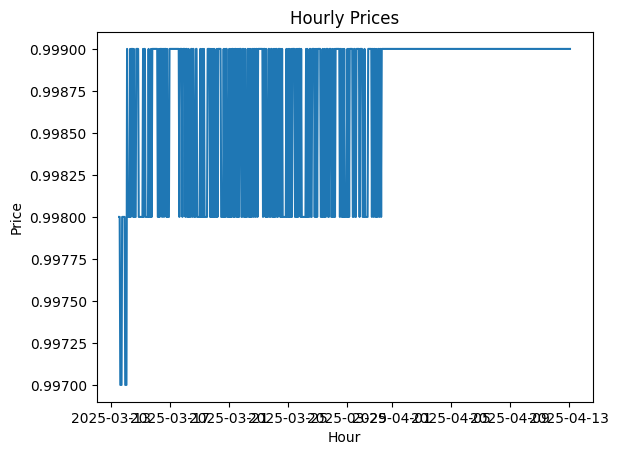

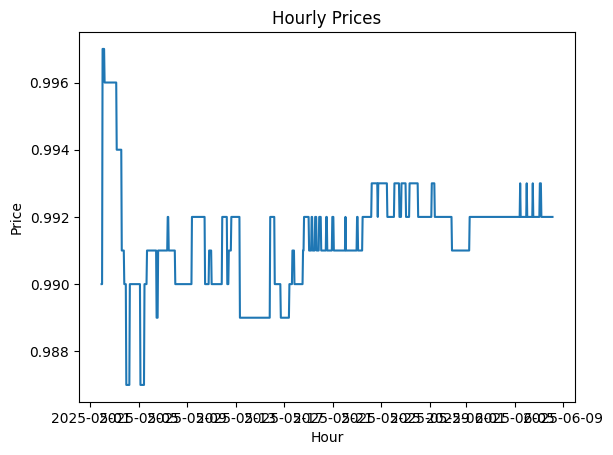

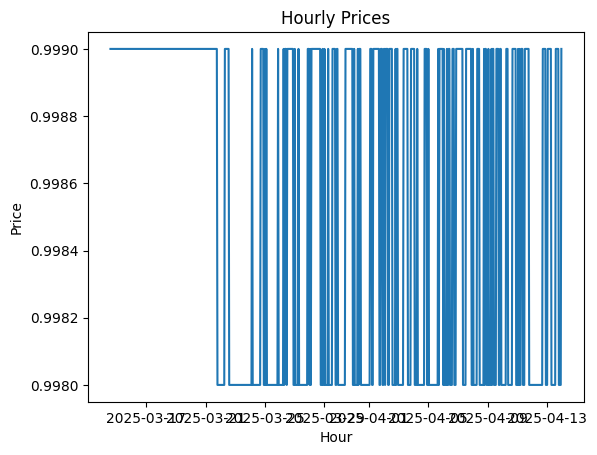

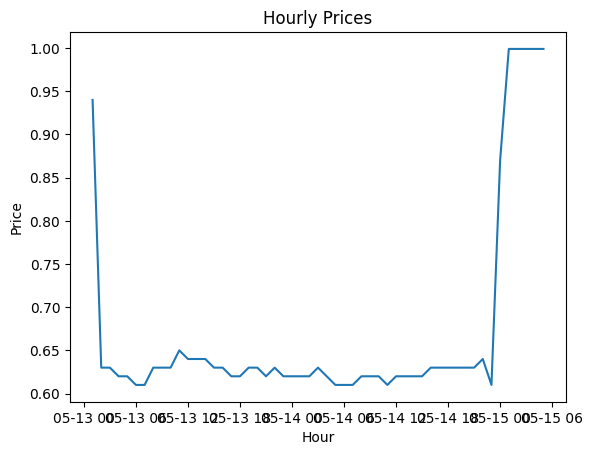

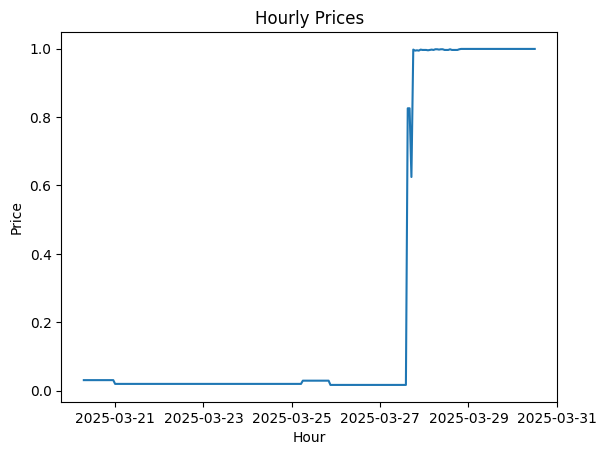

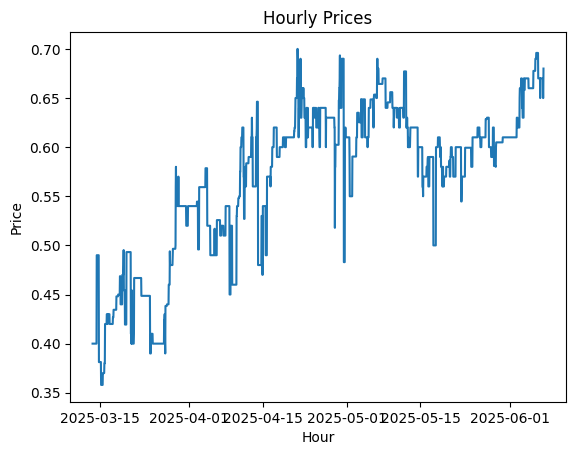

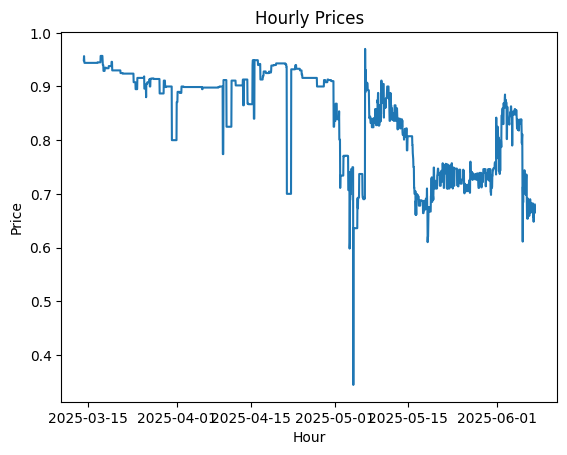

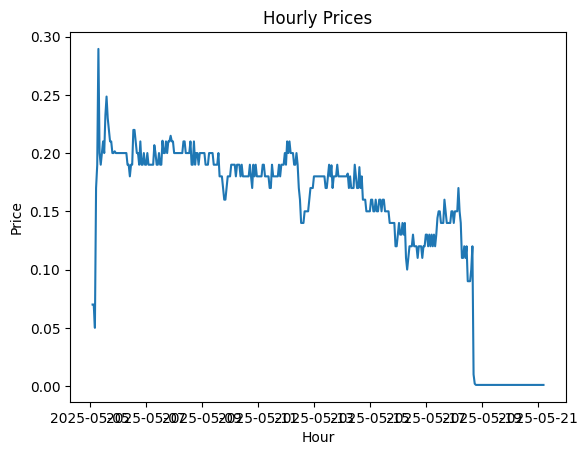

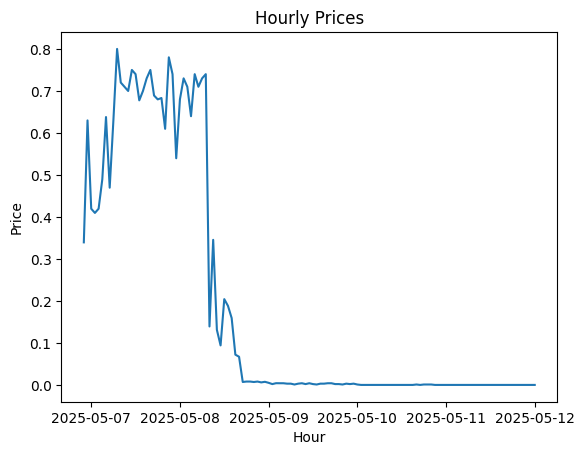

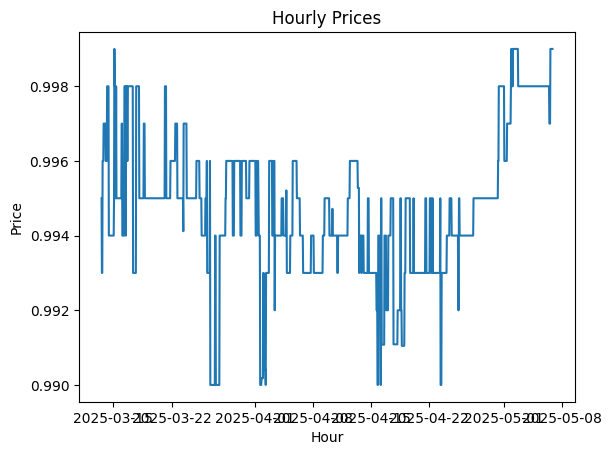

In [51]:
df_trades_copy['market_id'] = np.where(df_trades_copy['maker_asset_id'] == USDC_ID, df_trades_copy['taker_asset_id'], df_trades_copy['maker_asset_id'])

hourly_prices = df_trades_copy.groupby(['market_id', 'hour'])['price'].last().reset_index()

hourly_prices = (
    hourly_prices
    .set_index('hour')
    .groupby('market_id')[['price']]
    .resample('h')
    .ffill()
    .reset_index()
)

for i in range(10):
    m = np.random.choice(hourly_prices['market_id'].unique())
    plt.plot(hourly_prices[hourly_prices['market_id'] == m]['hour'], hourly_prices[hourly_prices['market_id'] == m]['price'])
    plt.xlabel('Hour')
    plt.ylabel('Price')
    plt.title('Hourly Prices')
    plt.show()


In [52]:
hourly_prices = hourly_prices.sort_values(['market_id','hour']).reset_index(drop=True)
hourly_prices['returns'] = hourly_prices.groupby('market_id')['price'].pct_change()
hourly_prices['log_returns'] = np.log(1+hourly_prices['returns'])  



# Figure 1

### Volume agrégé en USDC par jour sur ~1 539 marchés, mars–juin 2025.

Pics visibles autour des **grands événements politiques** (élections, décisions macro) ; volume de fond **~10–20M USDC/jour**, avec des journées à **>60M**. Comportement classique d'un carnet d'ordres event-driven : liquidité concentrée autour des résolutions. Pour un MM, le spread doit être élargi hors des fenêtres d'événement.

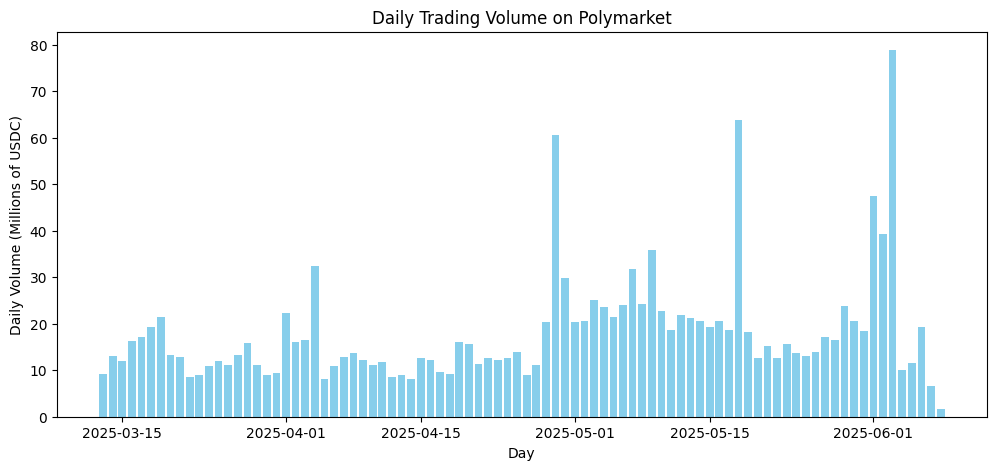

In [17]:
df_trades_copy["day"] = df_trades_copy["Date"].dt.floor("D")
daily_volumes = df_trades_copy.groupby("day")["usdc_amount"].sum() / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_volumes.index, daily_volumes.values, width=0.8, color="skyblue")
ax.set_xlabel("Day")
ax.set_ylabel("Daily Volume (Millions of USDC)")
ax.set_title("Daily Trading Volume on Polymarket")
plt.show()

### Nombre de comptes taker uniques par jour.

**~10 000–25 000** adresses actives/jour, avec des pics corrélés aux pics de volume. Le ratio volume/wallets implique une hétérogénéité forte — confirmée par la distribution percentile suivante.

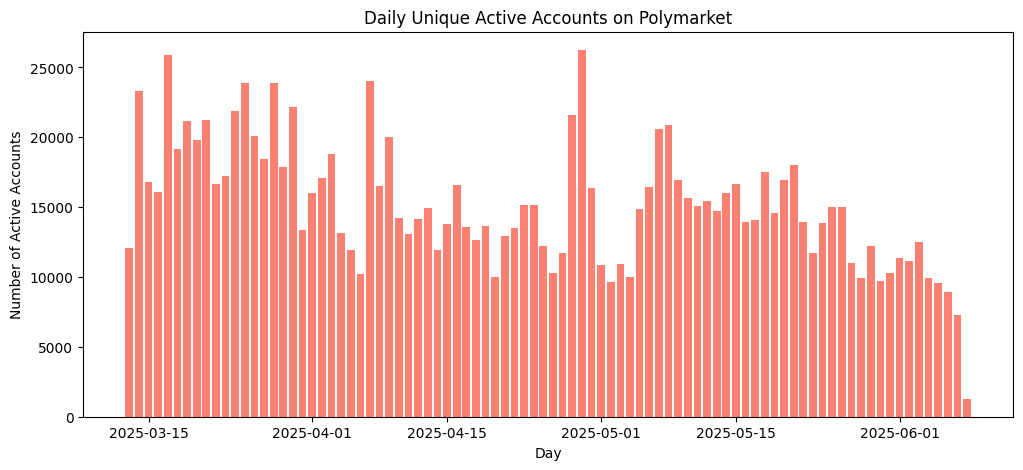

In [18]:
daily_users = df_trades_copy.groupby("day")["taker"].nunique()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(daily_users.index, daily_users.values, width=0.8, color="salmon")
ax.set_xlabel("Day")
ax.set_ylabel("Number of Active Accounts")
ax.set_title("Daily Unique Active Accounts on Polymarket")
plt.show()  

### Percentiles p50, p95, p99 du volume wallet journalier, échelle log.

Écart **p99 / p50 ~ 3 ordres de grandeur** : distribution très concentrée, cohérente avec une loi de Pareto. Stylized fact partagé avec les marchés traditionnels (cf. études TAQ sur NYSE). Un MM doit surveiller les **whale wallets** (p99) : leur flux est potentiellement informé et adverse.

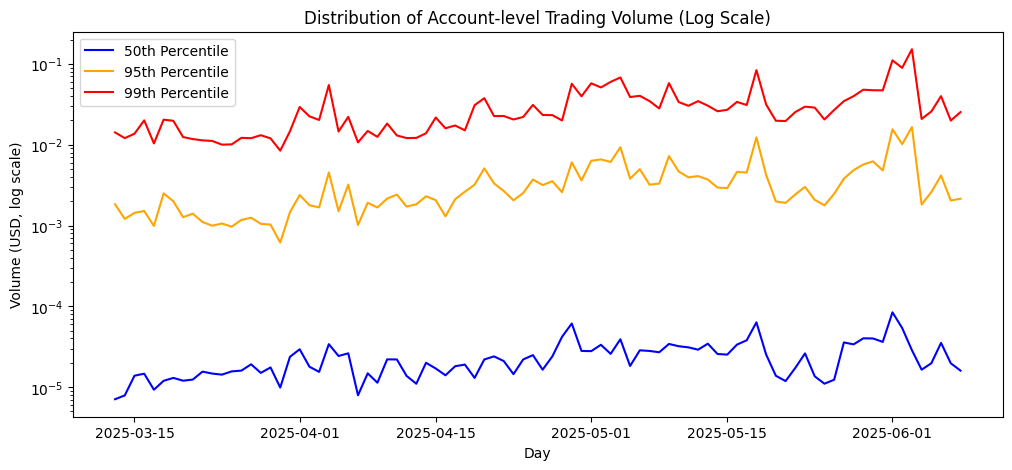

In [19]:
percentiles_data = []
unique_days = sorted(df_trades_copy['day'].unique())

for day in unique_days:
    df_day = df_trades_copy[df_trades_copy['day'] == day]
    
    # Volume accumulé par wallet ce jour-là
    m_vol = df_day.groupby('maker')['usdc_amount'].sum()
    t_vol = df_day.groupby('taker')['usdc_amount'].sum()
    day_wallet_vols = m_vol.add(t_vol, fill_value=0)
    
    percentiles_data.append({
        'day': day,
        'p50': day_wallet_vols.quantile(0.50),
        'p95': day_wallet_vols.quantile(0.95),
        'p99': day_wallet_vols.quantile(0.99)
    })

df_pct = pd.DataFrame(percentiles_data).set_index('day')

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_yscale('log')
ax.plot(df_pct.index, df_pct['p50'] / 1e6, label='50th Percentile', color='blue')
ax.plot(df_pct.index, df_pct['p95'] / 1e6, label='95th Percentile', color='orange')
ax.plot(df_pct.index, df_pct['p99'] / 1e6, label='99th Percentile', color='red')
ax.set_xlabel("Day")
ax.set_ylabel("Volume (USD, log scale)")
ax.set_title("Distribution of Account-level Trading Volume (Log Scale)")
ax.legend()
plt.show()

# Distribution log-return par marché

Histogramme des log-returns horaires (filtrés `|log(1+r)| > 1e-4`) vs densité normale ajustée, pour les 10 marchés les plus liquides.


1


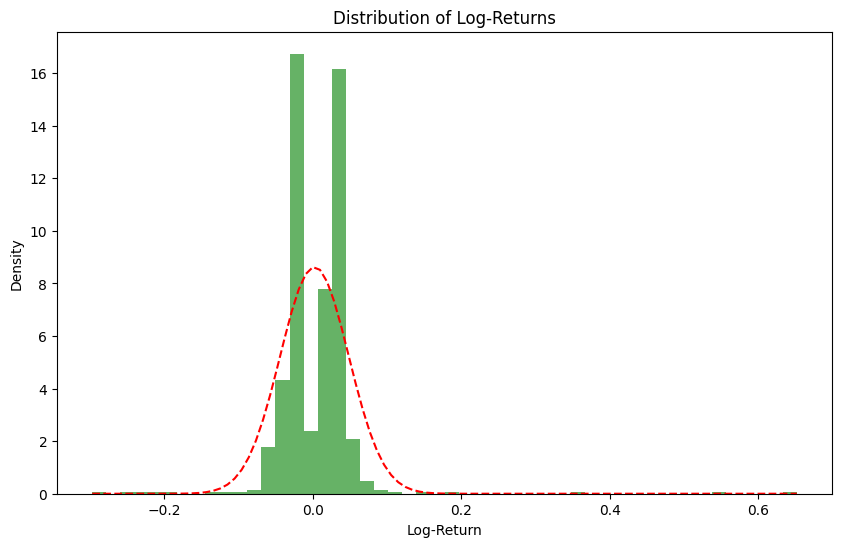

2


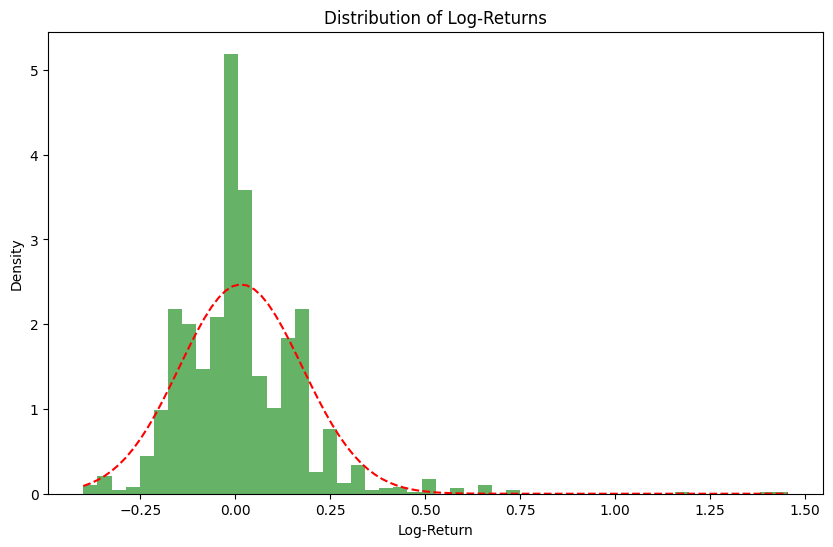

3


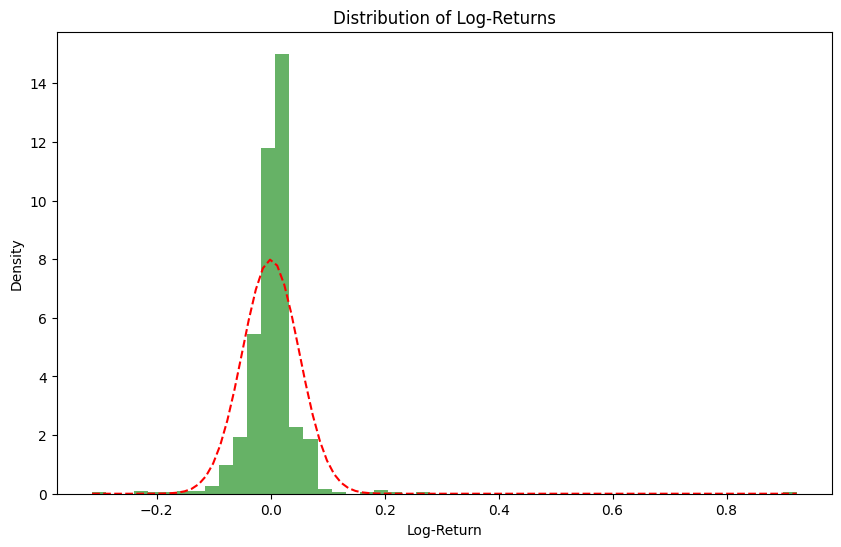

4


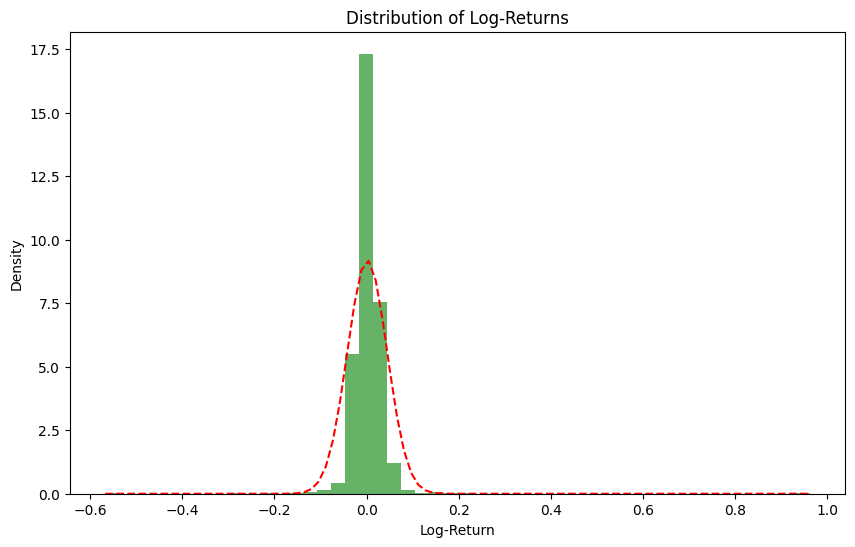

5


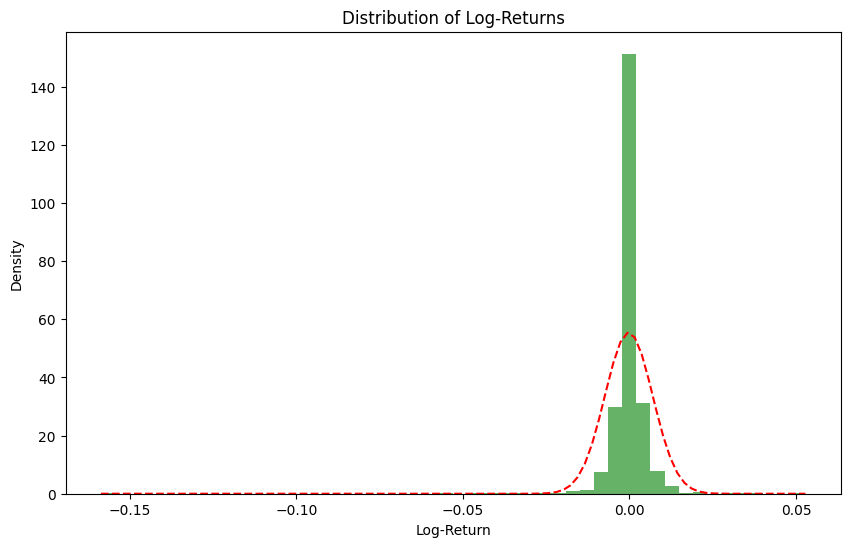

6


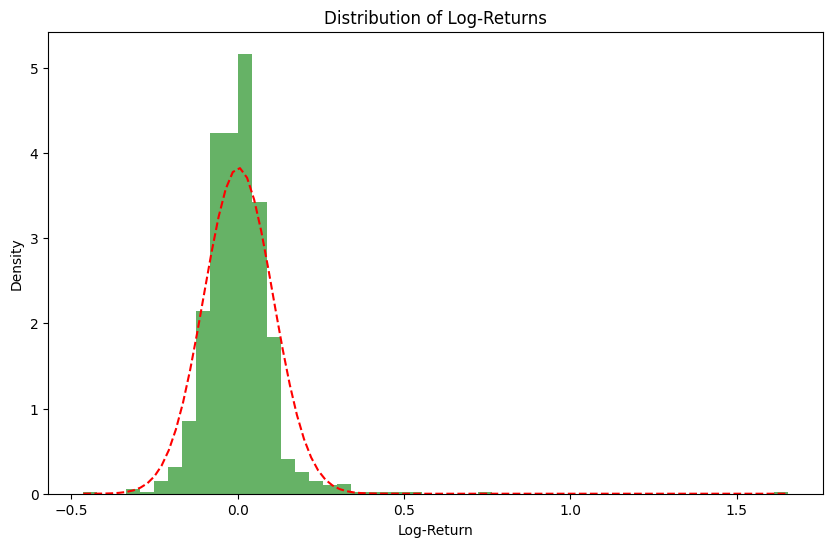

7


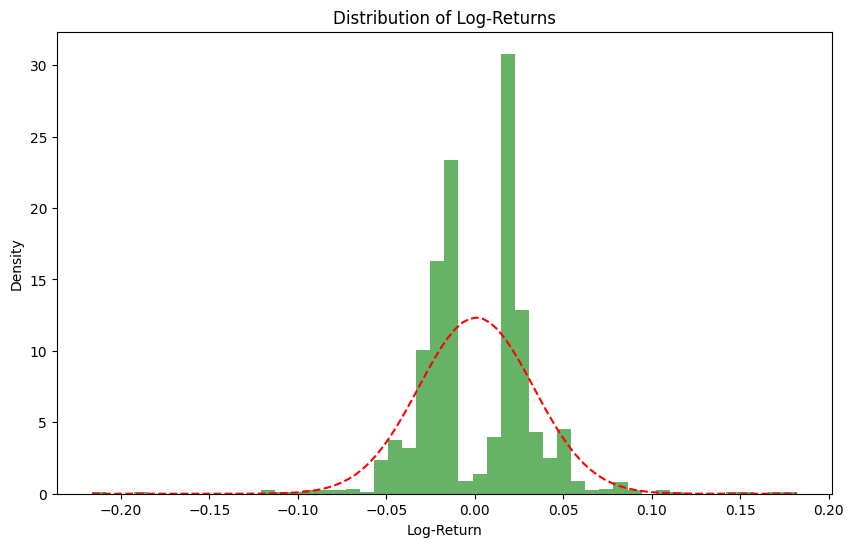

8


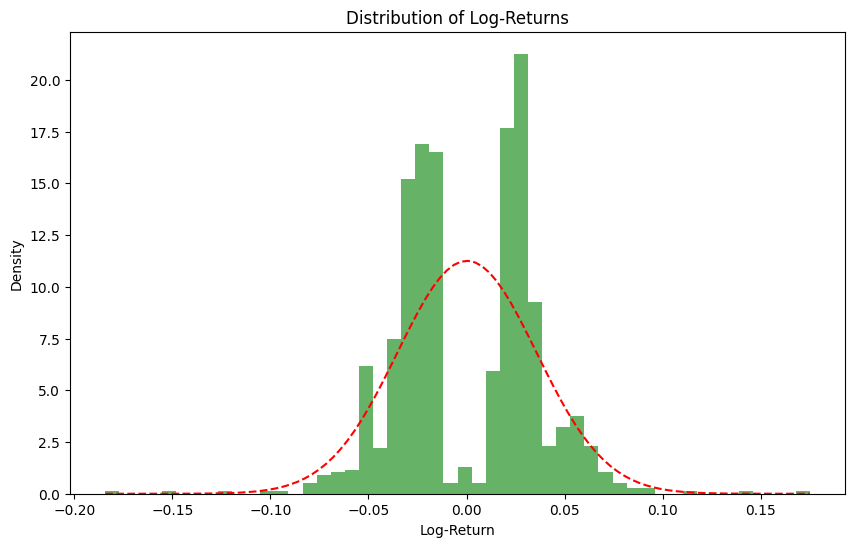

9


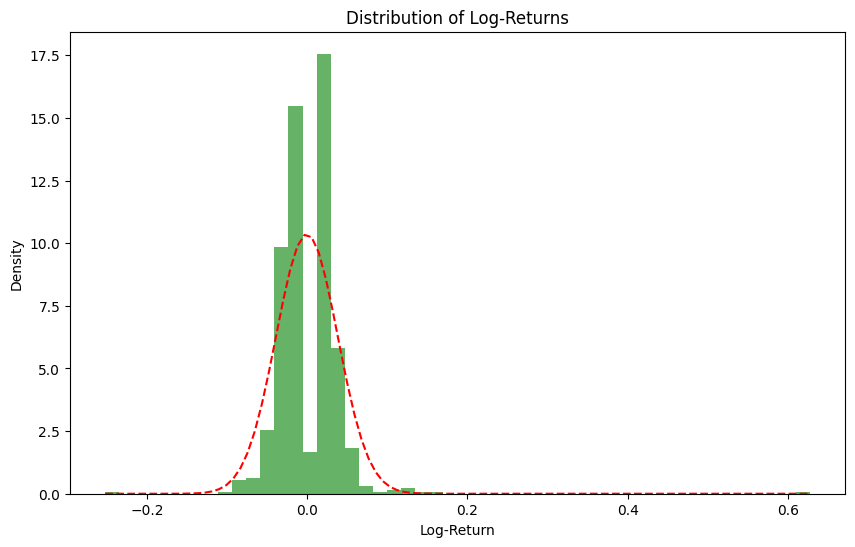

10


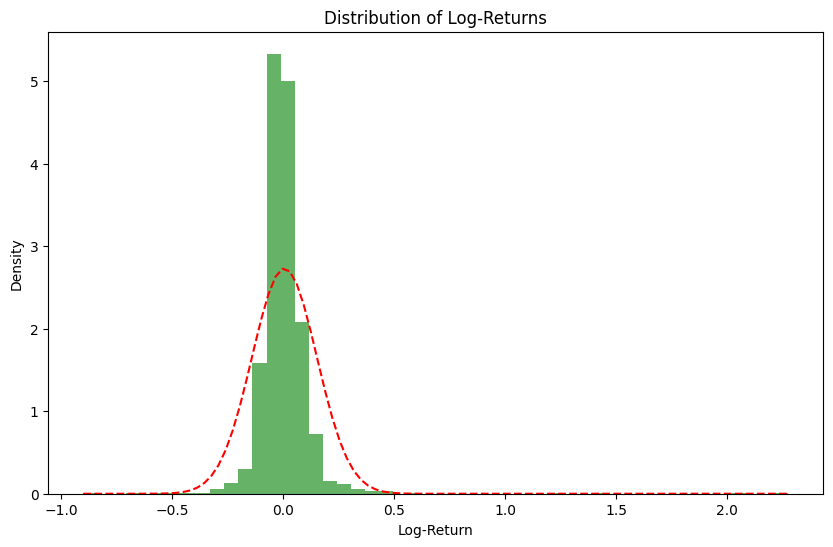

In [20]:
top_markets = hourly_prices['market_id'].value_counts().nlargest(10).index

for i in range(10):
    print(i+1)
    m = top_markets[i]
    log_returns = hourly_prices[hourly_prices['market_id'] == m]['returns'].dropna()
    log_returns = log_returns[log_returns.abs() > 1e-4]  # Exclure les log-returns nuls
    normal_dist = stats.norm(loc=log_returns.mean(), scale=log_returns.std())
    plt.figure(figsize=(10, 6))
    plt.hist(log_returns, bins=50, density=True, alpha=0.6, color='g')
    # Superpose la densité de la distribution normale
    x = np.linspace(log_returns.min(), log_returns.max(), 100)
    plt.plot(x, normal_dist.pdf(x), 'r--')
    plt.title('Distribution of Log-Returns')
    plt.xlabel('Log-Return')
    plt.ylabel('Density')
    plt.show()  


# Volatility Clustering

Volatilité rolling 24h des log-returns (std glissante) par marché.

Clustering visuel  : les périodes agitées se regroupent. 

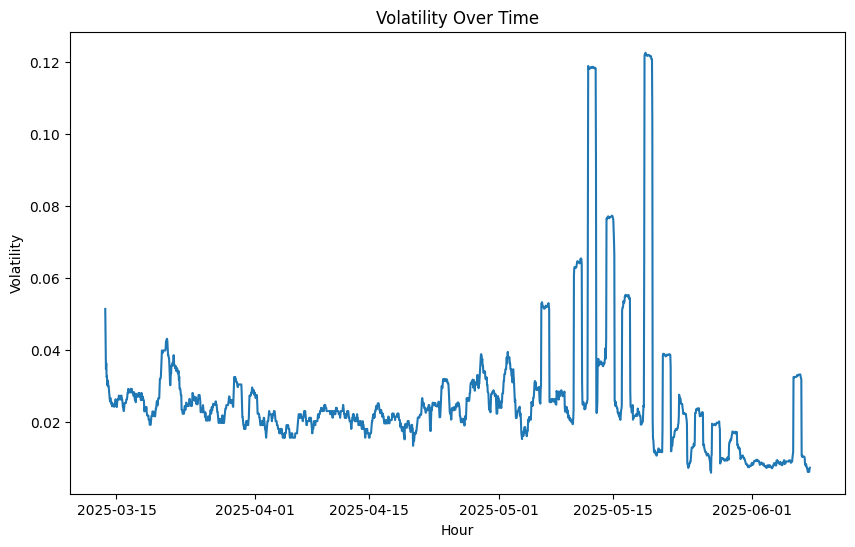

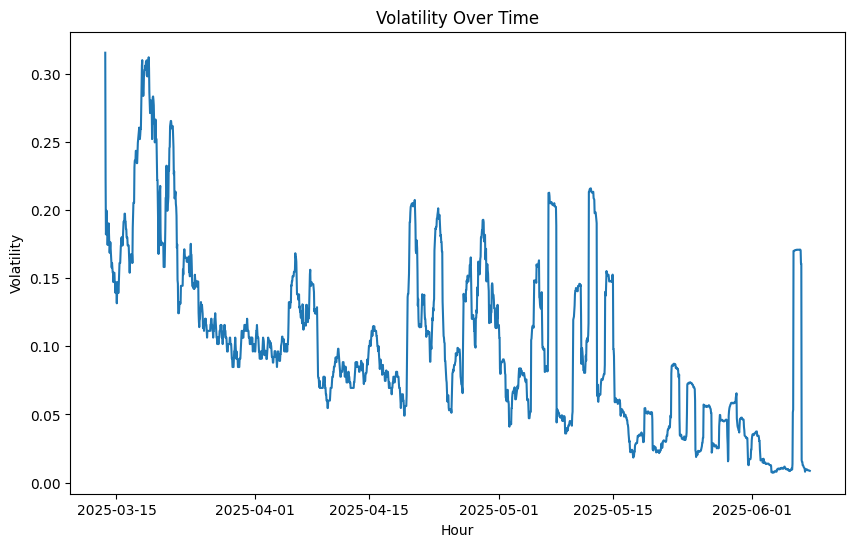

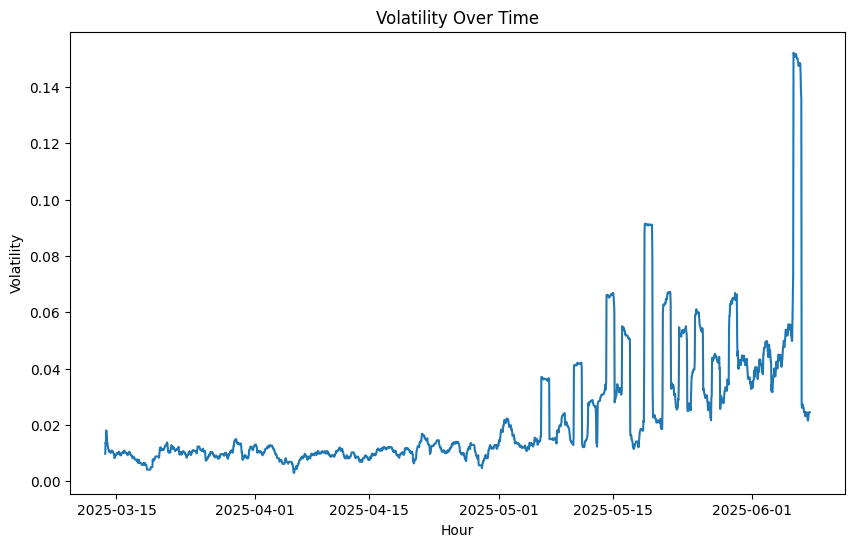

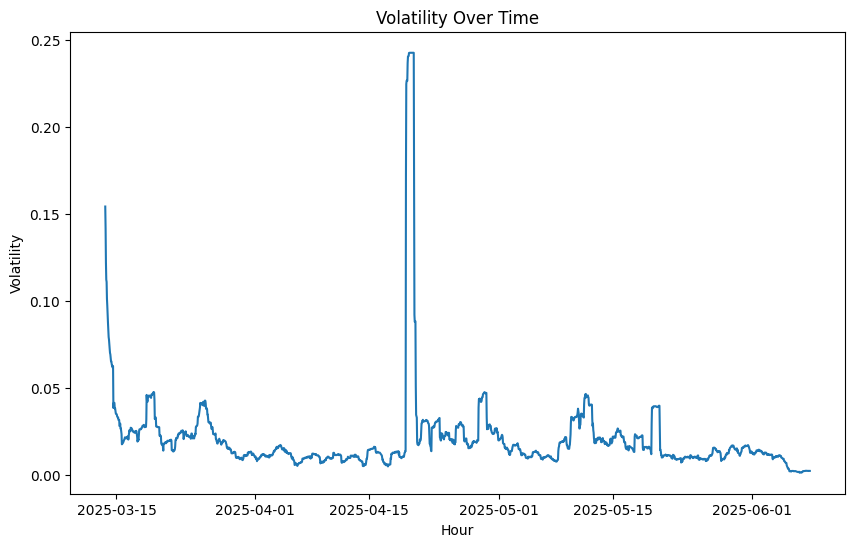

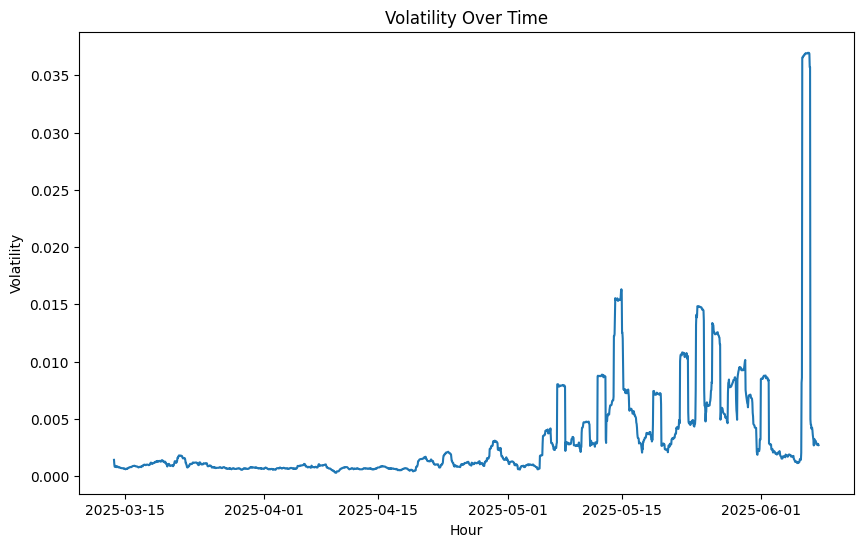

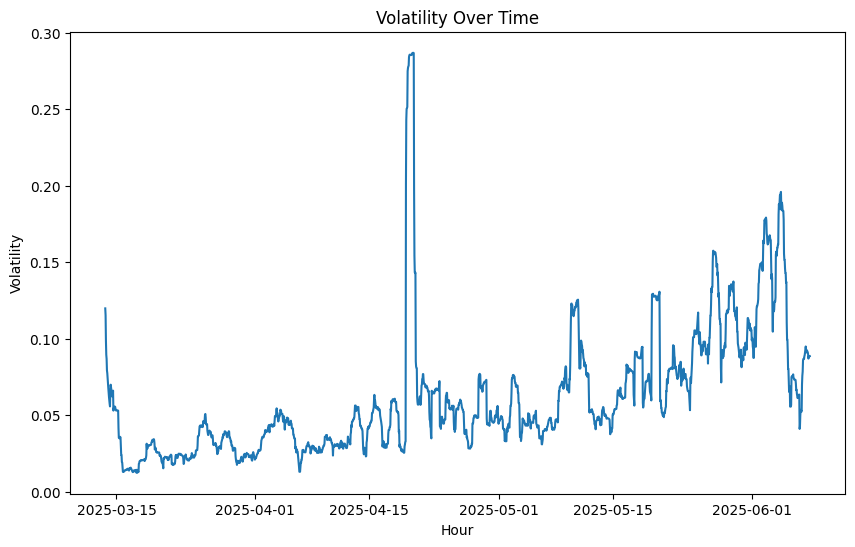

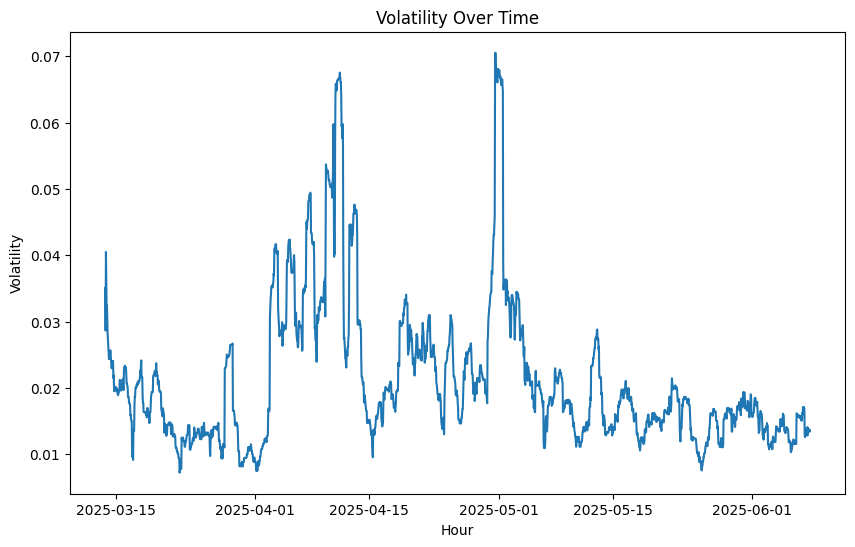

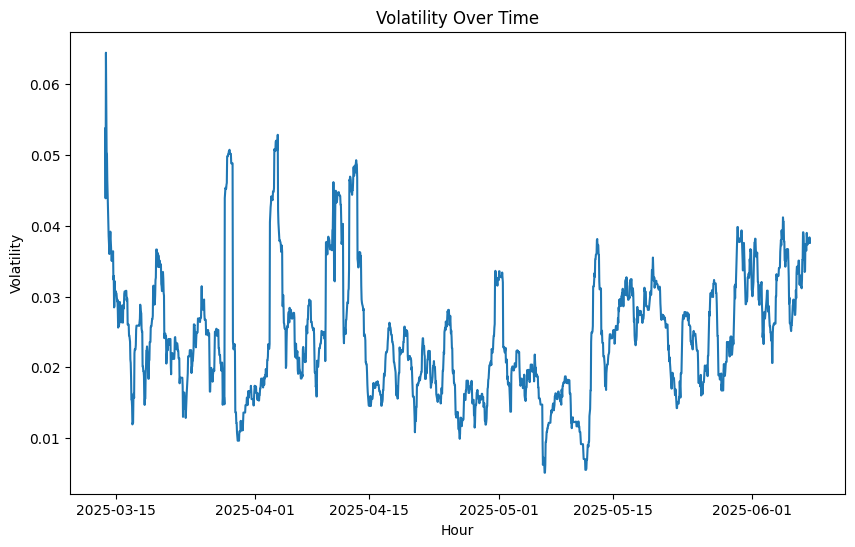

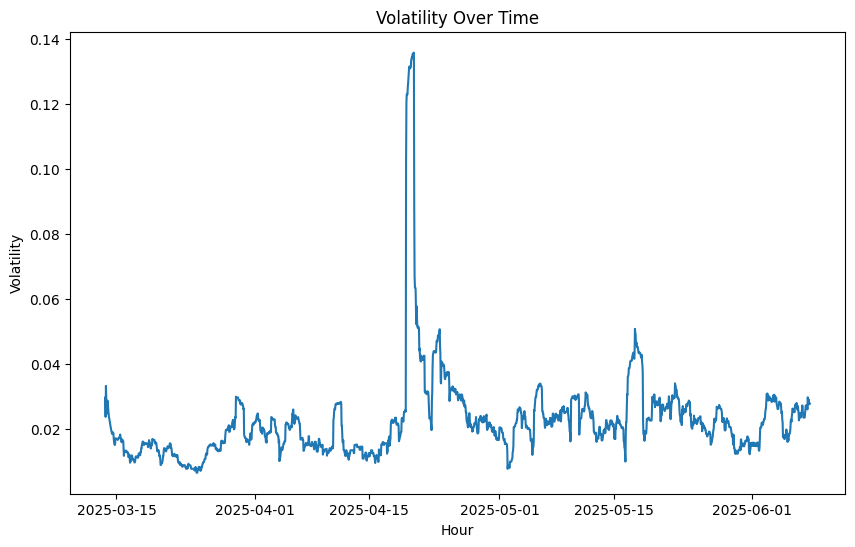

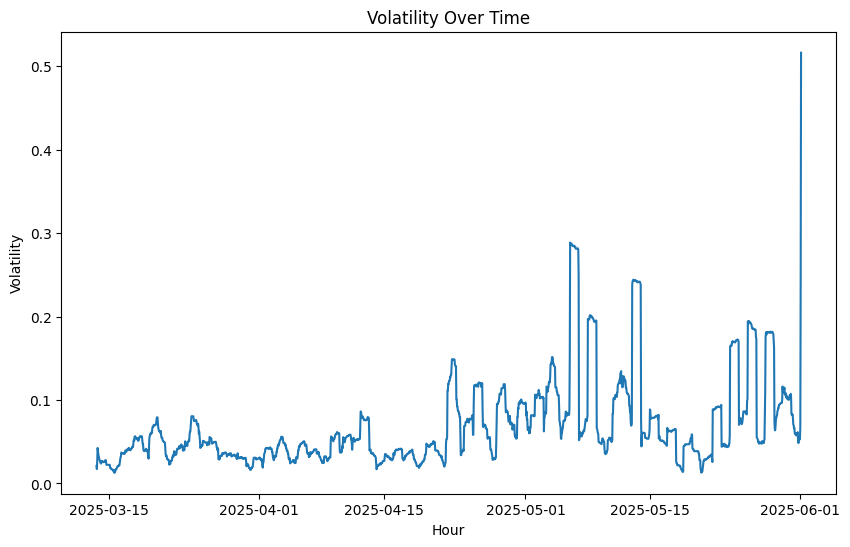

In [60]:
hourly_prices = hourly_prices.sort_values(['market_id', 'hour']).reset_index(drop=True)

hourly_prices['volatility'] = (
    hourly_prices.groupby('market_id')['log_returns']
    .transform(lambda x: x.rolling(window=24, min_periods=2).std())
)
for i in range(10):
    m = top_markets[i]
    plt.figure(figsize=(10, 6))
    plt.plot(hourly_prices[hourly_prices['market_id'] == m]['hour'], hourly_prices[hourly_prices['market_id'] == m]['volatility'])
    plt.title('Volatility Over Time')
    plt.xlabel('Hour')
    plt.ylabel('Volatility')
    plt.show()  


In [34]:
from statsmodels.stats.diagnostic import acorr_ljungbox

results = []

for m in hourly_prices['market_id'].unique():
    log_returns = hourly_prices[hourly_prices['market_id'] == m]['log_returns'].dropna() 
    if len(log_returns) < 50:
        continue    

    lb_stat= acorr_ljungbox(log_returns**2, lags=[5], return_df=False)
    results.append({
        'lb_stat': lb_stat['lb_stat'].values[0],
        'lb_pvalue': lb_stat['lb_pvalue'].values[0]
    })

results_df = pd.DataFrame(results)
results_df['lb_pvalue'] = results_df['lb_pvalue'].astype(float)

print(f"\nMarchés testés : {len(results_df)}")
print(f"Marchés avec clustering (p < 0.05) : {(results_df['lb_pvalue'] < 0.05).sum()} ({(results_df['lb_pvalue'] < 0.05).mean()*100:.1f}%)")
print(f"Marchés sans clustering (p >= 0.05) : {(results_df['lb_pvalue'] >= 0.05).sum()} ({(results_df['lb_pvalue'] >= 0.05).mean()*100:.1f}%)")
print(f"\nDistribution des p-values :")
print(results_df['lb_pvalue'].describe())

/Users/ayoub/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]



Marchés testés : 1337
Marchés avec clustering (p < 0.05) : 1029 (77.0%)
Marchés sans clustering (p >= 0.05) : 307 (23.0%)

Distribution des p-values :
count    1.336000e+03
mean     1.421301e-01
std      3.114482e-01
min      0.000000e+00
25%      5.312785e-23
50%      3.041151e-08
75%      3.090766e-02
max      1.000000e+00
Name: lb_pvalue, dtype: float64


Test d'autocorrélation sur les carrés des log-returns (lags = 5) pour confirmer le clustering de variance.

$$H_0 : \text{pas d'autocorrélation dans } r_t^2$$

1 029 / 1 337 marchés rejettent $H_0$ à 5% (77%) ; p-value médiane = 3e-8. La dépendance temporelle dans la variance est la règle, pas l'exception. Les 23% restants sont probablement des marchés trop peu liquides (peu de trades → séries trop courtes ou plates).

In [58]:
from arch import arch_model
import warnings
import pandas as pd
import numpy as np
from tqdm import tqdm

results_garch = []

for m in tqdm(hourly_prices['market_id'].unique()):
    subset = hourly_prices[hourly_prices['market_id'] == m].dropna(subset=['log_returns'])
    
    if len(subset) < 100:
        continue

    if subset['log_returns'].std() < 1e-4:
        continue

    subset = subset[subset['price'].between(0.05, 0.95)]
    if len(subset) < 100:
        continue
    
    q_low  = subset['log_returns'].quantile(0.01)
    q_high = subset['log_returns'].quantile(0.99)
    subset = subset[subset['log_returns'].between(q_low, q_high)]
    if len(subset) < 100:
        continue

    y = subset['log_returns'].values * 100
    
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = arch_model(y, vol='Garch', p=1, q=1, dist='t')
            res = model.fit(disp='off', options={'maxiter': 200})
        
        params = res.params
        alpha = params['alpha[1]']
        beta  = params['beta[1]']
        persistence = alpha + beta

        if persistence >= 1 or alpha < 0 or beta < 0:
            continue

        results_garch.append({
            'market_id': m,
            'alpha': alpha,
            'beta': beta,
            'persistence': persistence,
            'omega': params['omega'],
            'aic': res.aic,
            'converged': res.convergence_flag == 0
        })
    except:
        continue

df_garch = pd.DataFrame(results_garch)
df_garch = df_garch[df_garch['converged']]

  1%|          | 13/1539 [00:00<01:03, 24.08it/s]/Users/ayoub/Library/Python/3.9/lib/python/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  3%|▎         | 53/1539 [00:01<00:34, 42.89it/s]/Users/ayoub/Library/Python/3.9/lib/python/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
  6%|▋         | 100/1539 [00:03<01:02, 23.11it/s]/Users/ayoub/Library/Python/3.9/lib/python/site-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
 10%|▉         | 147/1539 [00:05<00:40, 34.28it/s]/Users/ayoub/Library/Python/3.9/lib/p

In [59]:
print(df_garch['persistence'].describe())
print(f"Marchés avec persistence > 0.9 : {(df_garch['persistence'] > 0.9).mean()*100:.1f}%")
print(f"Marchés non-stationnaires (>= 1) : {(df_garch['persistence'] >= 1).mean()*100:.1f}%")

count    479.000000
mean       0.658995
std        0.387920
min        0.000000
25%        0.295903
50%        0.870097
75%        0.993302
max        1.000000
Name: persistence, dtype: float64
Marchés avec persistence > 0.9 : 46.1%
Marchés non-stationnaires (>= 1) : 0.0%


Fit d'un GARCH(1,1)

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

479 marchés convergés sur ~1 539 ; persistence médiane = 0.87, 46% > 0.9, 0% ≥ 1. Persistence élevée = chocs de vol lents à se dissiper, ce qui suggère un carry de vol élevé sur Polymarket.

*Limite : GARCH(1,1) sur séries courtes (<200 obs) est mal identifié ; les 479 marchés retenus biaisent vers les marchés liquides.*